# Matplotlib 3D, Contours & Image Geometries: Beginner Guide

### 🌟 What Are 3D Plots, Contour Maps & Image Displays in Matplotlib?
Beyond basic 2D charts, Matplotlib supports specialized geometries: interactive **3D scatter and surface plots** (`projection='3d'`), **Contour elevation maps** (`contour`, `contourf`), and **2D matrix pixel rendering** (`imshow`).

This interactive guide loads and works directly with `data/raw_transactions.csv`, giving you real-world hands-on practice.

### 📚 Key Concepts Covered in this Notebook:
- **3D Projections (`projection='3d'`)**: How to initialize 3D coordinate space with X, Y, and Z axes.
- **3D Scatter Plot (`ax.scatter3D`)**: How to plot data points across 3 variables simultaneously.
- **3D Surface Plot (`ax.plot_surface`)**: How to render continuous 3D mathematical meshgrids and terrain.
- **Contour Lines & Maps (`ax.contour`, `ax.contourf`)**: How to visualize elevation and density level curves.
- **Matrix Heatmap Display (`ax.imshow`)**: How to render 2D numerical arrays directly as pixel images.
- **Polar Radar Coordinates (`projection='polar'`)**: How to plot circular radar profiles.


In [1]:
# Step 1: Import all necessary libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

# Step 2: Set clean visual defaults
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 10

# Step 3: Load the transactions dataset
csv_path = 'data/raw_transactions.csv' if os.path.exists('data/raw_transactions.csv') else '../data/raw_transactions.csv'
df = pd.read_csv(csv_path)

# Step 4: Ensure dates and numeric values are clean
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='mixed', errors='coerce')
df['transaction_amount'] = pd.to_numeric(df['transaction_amount'], errors='coerce')
df['account_age_months'] = pd.to_numeric(df['account_age_months'], errors='coerce')
df['is_fraud'] = pd.to_numeric(df['is_fraud'], errors='coerce').fillna(0).astype(int)
df = df.dropna(subset=['transaction_amount', 'transaction_date']).reset_index(drop=True)

print(f"✅ Successfully loaded {len(df)} transactions from {csv_path}")
df.head(3)

✅ Successfully loaded 14262 transactions from ../data/raw_transactions.csv


,transaction_id,customer_id,merchant_id,transaction_amount,card_type,transaction_status,device_type,account_age_months,transaction_date,region,is_fraud
0,TX110686,C82845,M2697,1216.33,Visa,Failed,POS,56,2025-07-06 00:00:00,North,0
1,TX107170,C85674,M3868,324.99,MasterCard,Reversed,Desktop,112,2025-10-05 00:00:00,East,0
2,TX108328,C32431,M1461,136.66,Discover,Completed,ATM,68,2025-07-26 06:22:30,East,0


### 🔹 🔹 3D Canvas Initialization: `projection='3d'`
Demonstrates how to use `🔹 3D Canvas Initialization: `projection='3d'`` in Python. Saving and loading data properly ensures results are persistent, shareable across teams, and ready for downstream analysis. **Tip:** Always remember to include `self` as the first parameter in instance methods so Python knows which object instance is executing.

**Syntax:** `# 1. Create a 3D coordinate box`


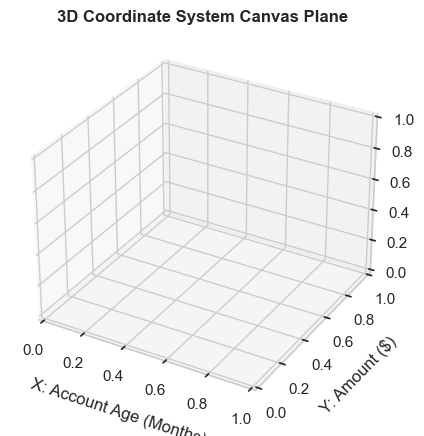

In [2]:
# 1. Create a 3D coordinate box
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(projection='3d')

# 2. Add labels for all 3 dimensions
ax.set_xlabel('X: Account Age (Months)', labelpad=8)
ax.set_ylabel('Y: Amount ($)', labelpad=8)
ax.set_zlabel('Z: Fraud Flag (0/1)', labelpad=8)
ax.set_title('3D Coordinate System Canvas Plane', fontsize=12, fontweight='bold')

plt.show()

### 🔹 🔹 3D Scatter Plots: `ax.scatter3D(x, y, z)`
Demonstrates how to use `🔹 3D Scatter Plots: `ax.scatter3D(x, y, z)`` in Python. Visualizations turn complex numerical data into clear, intuitive graphics, helping you spot trends, patterns, and anomalies quickly. **Tip:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.

**Syntax:** `sample = df.head(200)`


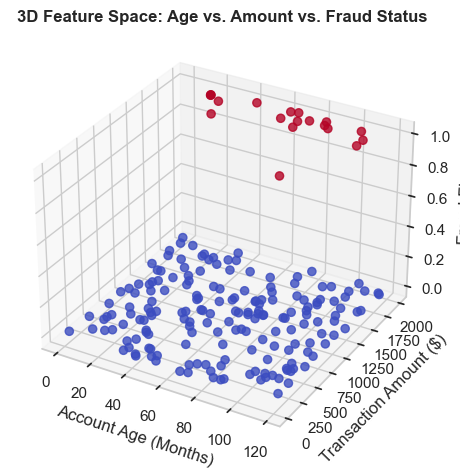

In [3]:
sample = df.head(200)

fig = plt.figure(figsize=(9, 5.5))
ax = fig.add_subplot(projection='3d')

# Plot Age (X), Amount (Y), Fraud Flag (Z)
p = ax.scatter3D(
    sample['account_age_months'], 
    sample['transaction_amount'], 
    sample['is_fraud'], 
    c=sample['is_fraud'], 
    cmap='coolwarm', 
    s=35, 
    alpha=0.8
)

ax.set_xlabel('Account Age (Months)')
ax.set_ylabel('Transaction Amount ($)')
ax.set_zlabel('Fraud Flag')
ax.set_title('3D Feature Space: Age vs. Amount vs. Fraud Status', fontsize=12, fontweight='bold')

plt.show()

### 🔹 🔹 3D Mathematical Surfaces: `ax.plot_surface(X, Y, Z)`
Demonstrates how to use `🔹 3D Mathematical Surfaces: `ax.plot_surface(X, Y, Z)`` in Python. Visualizations turn complex numerical data into clear, intuitive graphics, helping you spot trends, patterns, and anomalies quickly. **Tip:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.

**Syntax:** `# 1. Create a 2D grid of coordinates`


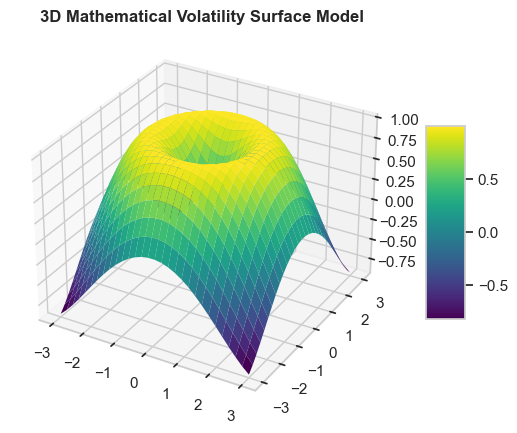

In [4]:
# 1. Create a 2D grid of coordinates
x = np.linspace(-3, 3, 30)
y = np.linspace(-3, 3, 30)
X, Y = np.meshgrid(x, y)

# 2. Calculate height Z using a mathematical wave function
Z = np.sin(np.sqrt(X**2 + Y**2))

# 3. Render the 3D surface
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

ax.set_title('3D Mathematical Volatility Surface Model', fontsize=12, fontweight='bold')
plt.show()

### 🔹 🔹 Contour Lines: `ax.contour(X, Y, Z)`
Demonstrates how to use `🔹 Contour Lines: `ax.contour(X, Y, Z)`` in Python. Visualizations turn complex numerical data into clear, intuitive graphics, helping you spot trends, patterns, and anomalies quickly. **Tip:** Test operations on a small sample of your dataset first (`df.head()` or `[:5]`) before running across all rows.

**Syntax:** `fig, ax = plt.subplots(figsize=(7, 4.5))`


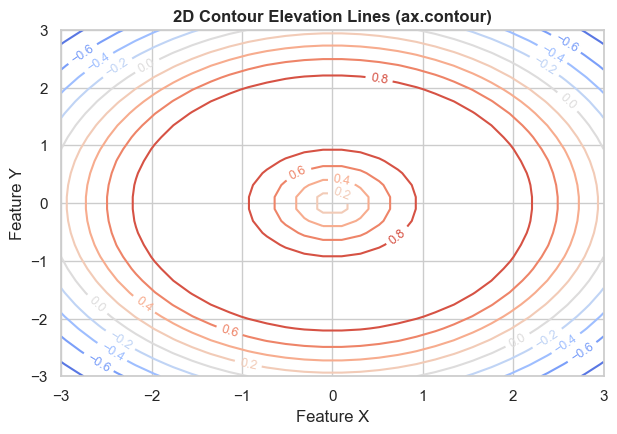

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))

# Draw 10 contour elevation levels
cs = ax.contour(X, Y, Z, levels=10, cmap='coolwarm')
ax.clabel(cs, inline=1, fontsize=9) # Add numeric labels to the lines

ax.set_title('2D Contour Elevation Lines (ax.contour)', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature X')
ax.set_ylabel('Feature Y')

plt.show()

### 🔹 🔹 Filled Contour Maps: `ax.contourf(X, Y, Z)`
Demonstrates how to use `🔹 Filled Contour Maps: `ax.contourf(X, Y, Z)`` in Python. Visualizations turn complex numerical data into clear, intuitive graphics, helping you spot trends, patterns, and anomalies quickly. **Tip:** `.apply()` runs a standard Python loop row-by-row. Whenever possible, use built-in vectorized operations (`df['a'] + df['b']`) which run up to 100x faster!.

**Syntax:** `fig, ax = plt.subplots(figsize=(7, 4.5))`


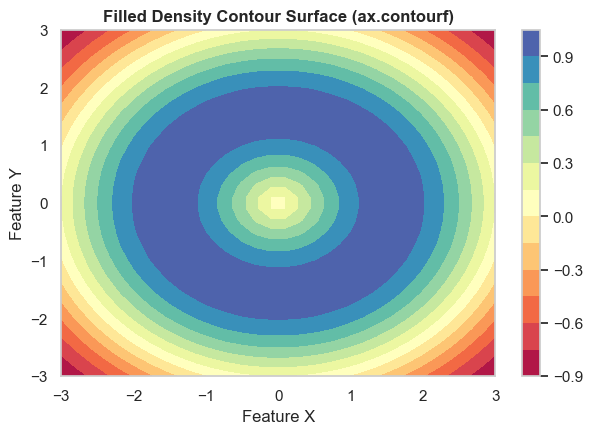

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))

# Fill contour levels with color
cf = ax.contourf(X, Y, Z, levels=15, cmap='Spectral')
fig.colorbar(cf, ax=ax)

ax.set_title('Filled Density Contour Surface (ax.contourf)', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature X')
ax.set_ylabel('Feature Y')

plt.show()

### 🔹 🔹 Matrix Pixel Display: `ax.imshow()`
Demonstrates how to use `🔹 Matrix Pixel Display: `ax.imshow()`` in Python. Visualizations turn complex numerical data into clear, intuitive graphics, helping you spot trends, patterns, and anomalies quickly. **Tip:** Test operations on a small sample of your dataset first (`df.head()` or `[:5]`) before running across all rows.

**Syntax:** `# 1. Calculate correlation table between numeric columns`


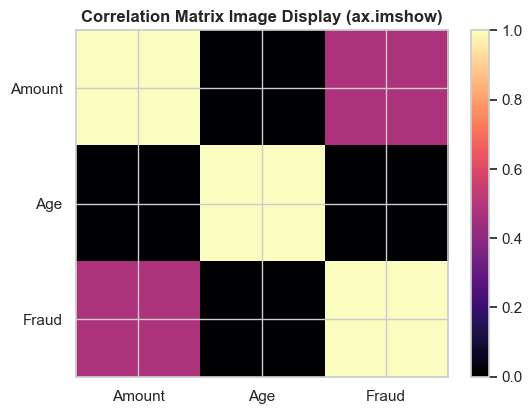

In [7]:
# 1. Calculate correlation table between numeric columns
corr_matrix = df[['transaction_amount', 'account_age_months', 'is_fraud']].corr().values

# 2. Display the matrix as a pixel image
fig, ax = plt.subplots(figsize=(6, 4.5))
im = ax.imshow(corr_matrix, cmap='magma', aspect='auto')
fig.colorbar(im)

# 3. Label the rows and columns
feature_names = ['Amount', 'Age', 'Fraud']
ax.set_xticks([0, 1, 2], feature_names)
ax.set_yticks([0, 1, 2], feature_names)
ax.set_title('Correlation Matrix Image Display (ax.imshow)', fontsize=12, fontweight='bold')

plt.show()

### 🔹 🔹 Polar Radar Charts: `projection='polar'`
Demonstrates how to use `🔹 Polar Radar Charts: `projection='polar'`` in Python. Visualizations turn complex numerical data into clear, intuitive graphics, helping you spot trends, patterns, and anomalies quickly. **Tip:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.

**Syntax:** `# 1. Define days of week and angles around the circle`


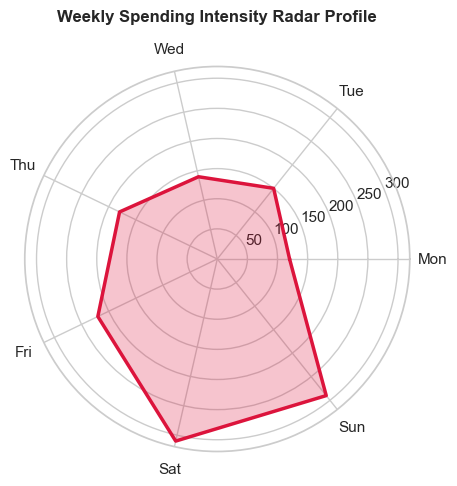

In [8]:
# 1. Define days of week and angles around the circle
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
angles = np.linspace(0, 2 * np.pi, len(days), endpoint=False).tolist()

# Complete the circular loop by repeating the first item
angles += angles[:1]
spend_scores = [120, 150, 140, 180, 220, 310, 290, 120]

# 2. Plot on polar axes
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection='polar')
ax.plot(angles, spend_scores, color='crimson', lw=2.5)
ax.fill(angles, spend_scores, color='crimson', alpha=0.25)

ax.set_thetagrids(np.degrees(angles[:-1]), days)
ax.set_title('Weekly Spending Intensity Radar Profile', fontsize=12, fontweight='bold', pad=15)

plt.show()